In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt


In [3]:
# Gathers all json in the directory and concatenates into a dataframe
paths = ['./Data/Luna - Spotify Streaming History', './Data/Kit - Spotify Streaming History', './Data/Madison - Spotify Streaming History']
folder_path = paths[0]

json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]

df_list = []
for file_name in json_files:
    full_path = os.path.join(folder_path, file_name)
    df_list.append(pd.read_json(full_path))

df = pd.concat(df_list, ignore_index=True)


In [4]:
# Convert string to datetime
df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('America/New_York')
#Sort values and reset index
df = df.sort_values(by='ts')
df = df.reset_index()

In [5]:
# Track, Artist, and Timestamp ordered by timestamp
print(df[['master_metadata_track_name', 'master_metadata_album_artist_name', 'ts']].head())


                    master_metadata_track_name  \
0                              Cold Hard Bitch   
1  All These Things I Hate (Revolve Around Me)   
2                                  Be Yourself   
3                                      Call Me   
4                               Bad Girlfriend   

  master_metadata_album_artist_name                        ts  
0                               Jet 2019-10-22 11:52:51-04:00  
1           Bullet For My Valentine 2019-10-22 11:52:57-04:00  
2                        Audioslave 2019-10-22 11:53:04-04:00  
3                         Shinedown 2019-10-22 11:56:46-04:00  
4               Theory of a Deadman 2019-10-22 12:00:12-04:00  


In [6]:
# Track Listen Counter
def track_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_track_name'].value_counts().sort_values(ascending=ascending)



In [7]:
# Artist Listen Counter
def artist_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_album_artist_name'].value_counts().sort_values(ascending=ascending)




In [8]:
# Album Listen Counter
def album_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_album_album_name'].value_counts().sort_values(ascending=ascending)


In [17]:
# Printing results of listening counts

print('Track Listen Counts:\n', track_counts(df).head(), '\n\n\n')

print('Artist Listen Counts:\n', artist_counts(df).head(), '\n\n\n')

print('Album Listen Counts:\n', album_counts(df).head(), '\n\n\n')


Track Listen Counts:
 master_metadata_track_name
midnight love             4048
So Long                   2241
505                       2179
I / Me / Myself           1836
Fluorescent Adolescent    1806
Name: count, dtype: int64 



Artist Listen Counts:
 master_metadata_album_artist_name
James Marriott         14587
girl in red            13279
Fly By Nightcore       12386
Cavetown               12357
My Chemical Romance    12349
Name: count, dtype: int64 



Album Listen Counts:
 master_metadata_album_album_name
Three Cheers for Sweet Revenge    8056
Favourite Worst Nightmare         5610
Live at Hoxton Hall               5524
Hamilton                          5324
Poké & Chill                      4645
Name: count, dtype: int64 





In [10]:
counts = track_counts(df)

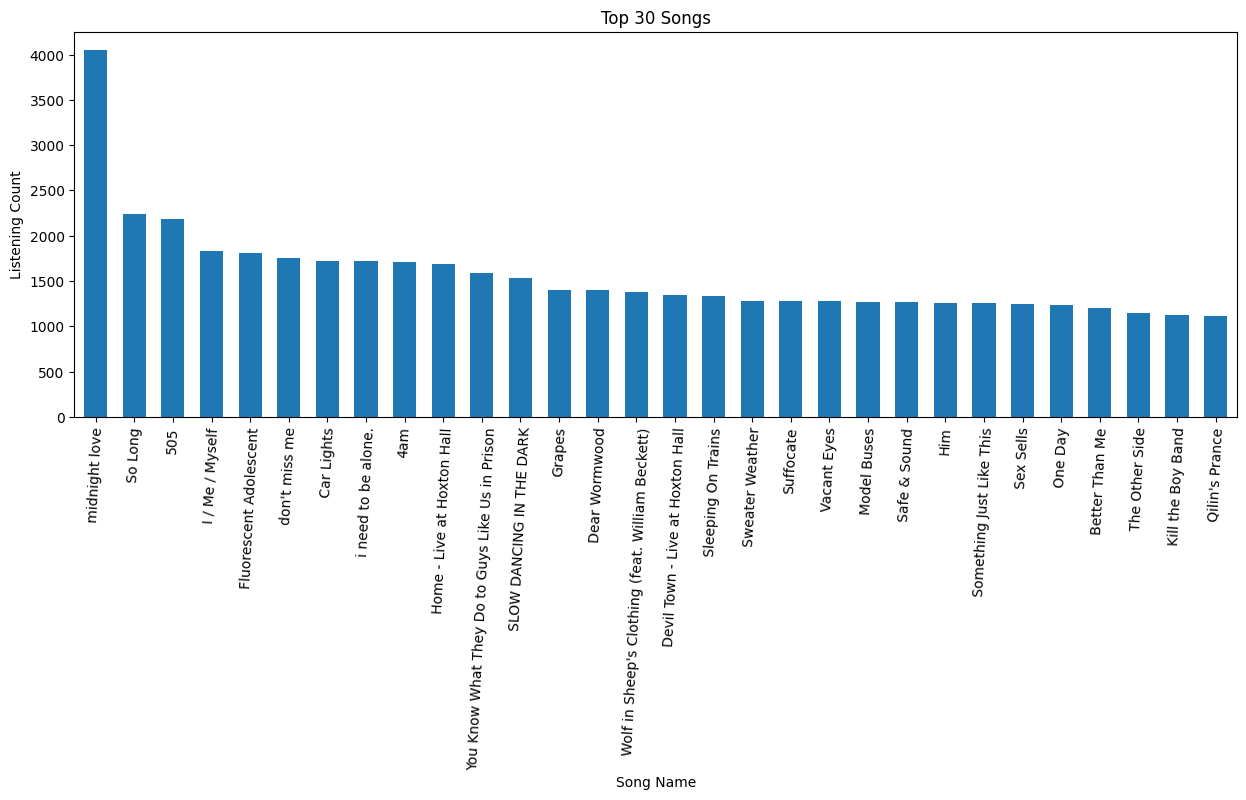

In [11]:
# plt.rcParams['font.sans-serif'] = [
#     'Arial Unicode MS',  
#     'AppleGothic',   
#     'PingFang SC',   
#     'Malgun Gothic', 
#     'Hiragino Sans',     
#     'Yu Gothic',         
#     'SimHei',        
#     'Arial'          
# ]
# plt.rcParams['axes.unicode_minus'] = False
counts[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.title("Top 30 Songs")
plt.xlabel("Song Name")
plt.ylabel("Listening Count")
plt.show()

Text(0, 0.5, 'Listening Count')

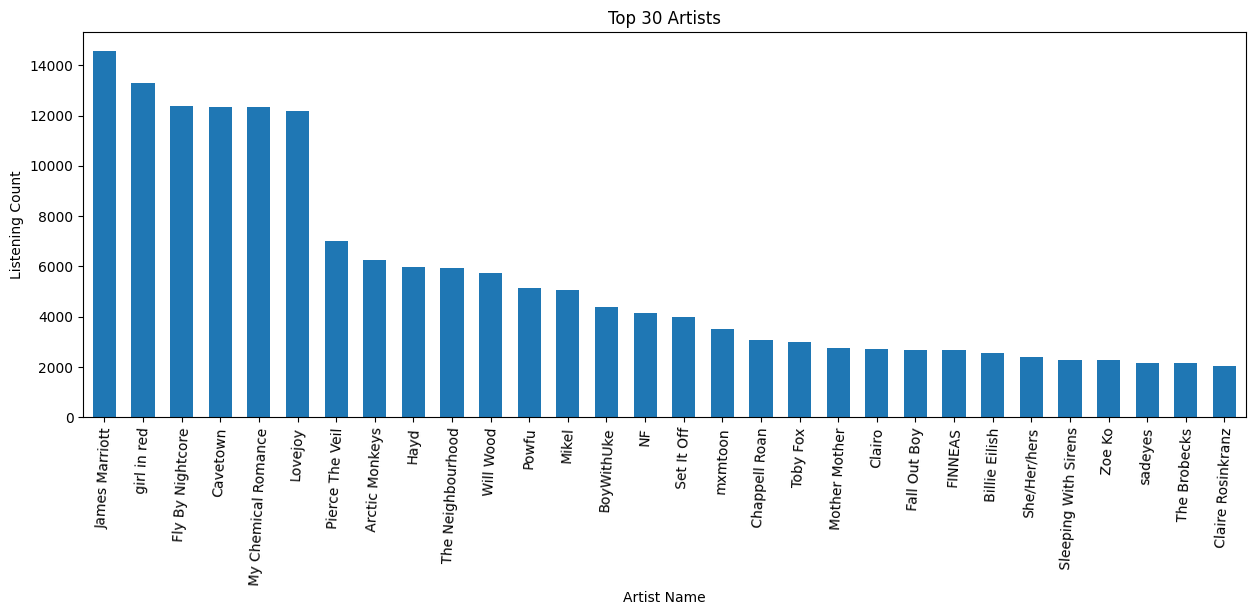

In [12]:
#meshs code:
counts = artist_counts(df)
counts[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.title("Top 30 Artists")
plt.xlabel("Artist Name")
plt.ylabel("Listening Count")

In [13]:
dftime = df[(df['ts'] >= '01-01-2025') & (df['ts'] < '01-02-2025')]['ts']
dftime

262203   2025-01-01 12:45:54-05:00
262204   2025-01-01 12:48:29-05:00
262205   2025-01-01 12:51:56-05:00
262206   2025-01-01 12:53:44-05:00
262207   2025-01-01 12:53:54-05:00
                    ...           
262269   2025-01-01 20:15:24-05:00
262270   2025-01-01 20:20:14-05:00
262271   2025-01-01 20:23:55-05:00
262272   2025-01-01 20:27:16-05:00
262273   2025-01-01 20:31:18-05:00
Name: ts, Length: 71, dtype: datetime64[us, America/New_York]

Text(0.5, 1.0, 'Songs Listened to by Hour of Day')

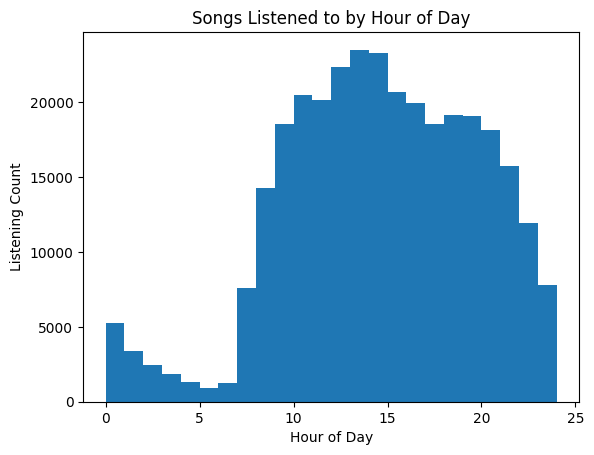

In [14]:
plt.hist(df[(df['ts'] >= '01-01-2000') & (df['ts'] < '01-01-2026')]['ts'].dt.hour, bins=24, range=(0, 24))
plt.xlabel("Hour of Day")
plt.ylabel("Listening Count")
plt.title("Songs Listened to by Hour of Day")

master_metadata_track_name
So Long                               110
Car Lights                            101
midnight love                          96
Don't Blame Me                         94
Better Than Me                         82
                                     ... 
Good Graces                             1
See You Again (feat. Charlie Puth)      1
CITY OF ANGELS                          1
Let Me Down Slowly                      1
Gentle Earthquakes                      1
Name: count, Length: 4205, dtype: int64

<Axes: xlabel='master_metadata_track_name'>

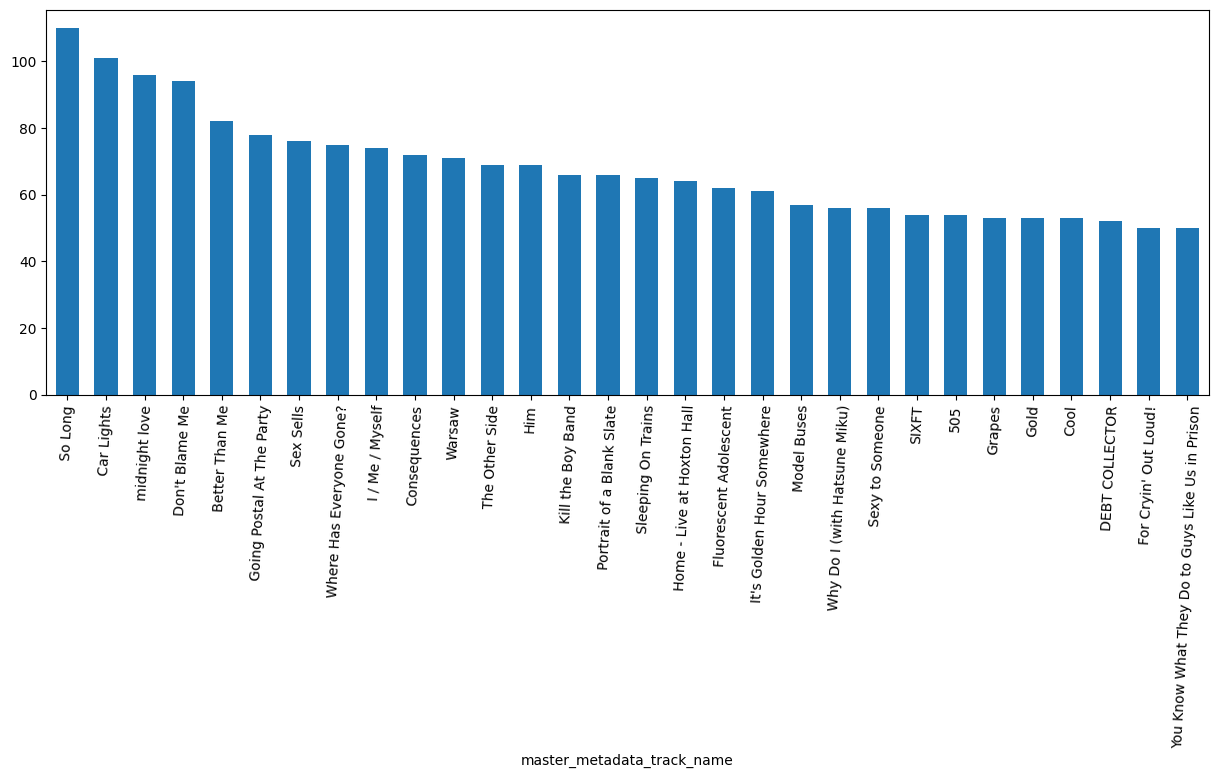

In [18]:
skipped = df[df['skipped']]['master_metadata_track_name'].value_counts().sort_values(ascending=False)

skipped[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)